In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
import umap

C:\Users\noton\miniconda3\envs\ReL\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("data_to_MF/smiles_list_all.csv")
made_by = pd.DataFrame(data['made_by'], columns=['made_by'])
data

,SMILES,made_by
0,Cn1cccc1-c1cccc2c1Nc1ccccc1O2,F
1,CN(Cc1ccc(P(=O)(c2ccccc2)c2cc(-c3ccc4ncoc4c3)c...,F
2,CC1(C)c2ccccc2Nc2c(-c3ccc(C(=C4C(=O)c5ccccc5C4...,F
3,N#Cc1cc(C#N)c(-c2ncsc2C#Cc2c(F)c(F)cc(F)c2F)c(...,F
4,C#CC1NC(C(=C)c2cc(C#N)c(C#N)c(C#N)c2)COC1n1c2c...,F
...,...,...
126425,Cn1cnc2ccc([SH]3C=CC=C3C=C(C#N)C#N)cc21,e=1
126426,COc1cc(OC)cc(-c2cncc(-c3cccnc3)c2)c1,e=1
126427,N#CC(C#N)=C1C(=Cc2ccc(-c3ccccc3C(=O)C(F)(F)F)c...,e=1
126428,CNc1cc(-c2ccc3c(c2)C(=O)C=CC3=O)cc(-c2c(F)c(F)...,e=1


In [3]:
mf_2 = []
for i in range(0, len(data)):
    mol_2 = Chem.MolFromSmiles(data["SMILES"][i])
    fp_2 = AllChem.GetMorganFingerprintAsBitVect(mol_2, 2, 2048)
    mf_2.append(np.array(fp_2, int))

df = pd.DataFrame(mf_2)
df = df.add_prefix('MF2_')
print(df.shape)
df

(126430, 2048)


,MF2_0,MF2_1,MF2_2,MF2_3,MF2_4,MF2_5,MF2_6,MF2_7,MF2_8,MF2_9,...,MF2_2038,MF2_2039,MF2_2040,MF2_2041,MF2_2042,MF2_2043,MF2_2044,MF2_2045,MF2_2046,MF2_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126425,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
126426,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
126427,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
126428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# UMAP
X = np.array(df)
reducer = umap.UMAP(random_state=42)
X_2d = reducer.fit_transform(X)
df_umap = pd.DataFrame(X_2d)
df_umap = df_umap.add_prefix('UMAP_')
df_umap

C:\Users\noton\miniconda3\envs\ReL\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
C:\Users\noton\miniconda3\envs\ReL\lib\site-packages\umap\spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\noton\miniconda3\envs\ReL\lib\site-packages\umap\spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\noton\miniconda3\envs\ReL\lib\site-packages\umap\spectral.py:550: UserWarning: Spectral initialisation failed! The eigenve

,UMAP_0,UMAP_1
0,-6.830436,-3.269613
1,10.622682,-4.564980
2,9.044916,-5.429095
3,2.157265,2.633569
4,-4.150690,3.916986
...,...,...
126425,-2.625468,-0.060011
126426,2.069695,-4.260004
126427,-6.725378,8.354657
126428,2.644141,-1.514749


In [5]:
df_umap = pd.concat([df_umap, made_by], axis=1, join='inner')
df_umap.head()

,UMAP_0,UMAP_1,made_by
0,-6.830436,-3.269613,F
1,10.622682,-4.564980,F
2,9.044916,-5.429095,F
3,2.157265,2.633569,F
4,-4.150690,3.916986,F


In [6]:
MF_umap_F = df_umap[df_umap['made_by'] == 'F']
MF_umap_E = df_umap[df_umap['made_by'] == 'E']
MF_umap_e1 = df_umap[df_umap['made_by'] == 'e=1']

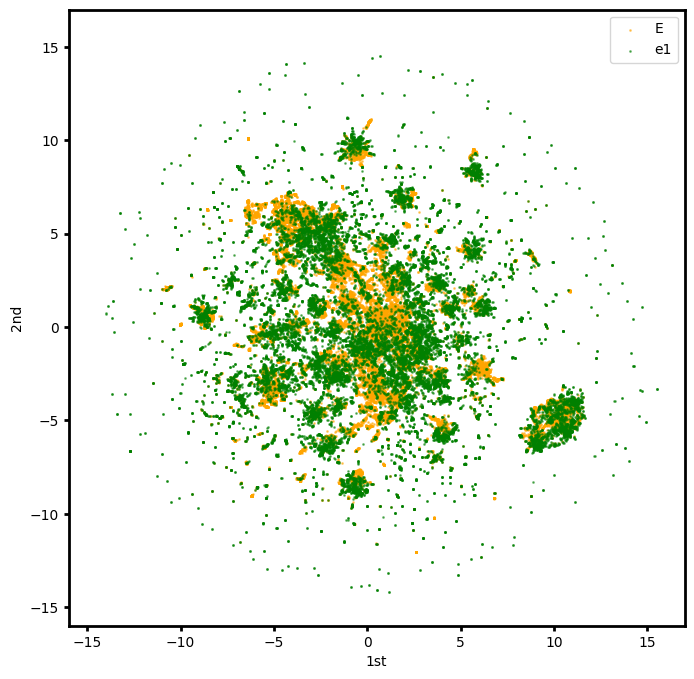

In [7]:
fig = plt.figure(figsize=(8,8))
plt.scatter(MF_umap_E['UMAP_0'], MF_umap_E['UMAP_1'], color='orange', label='E', s=1, alpha=0.5)
plt.scatter(MF_umap_e1['UMAP_0'], MF_umap_e1['UMAP_1'], color='green', label='e1', s=1, alpha=0.5)
plt.xlabel("1st")
plt.ylabel("2nd")
plt.xlim(-16, 17)
plt.ylim(-16, 17)
plt.xticks(np.arange(-15, 16, 5))
plt.yticks(np.arange(-15, 16, 5))
plt.gca().set_aspect('equal')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(width=2)
plt.legend()
plt.show()

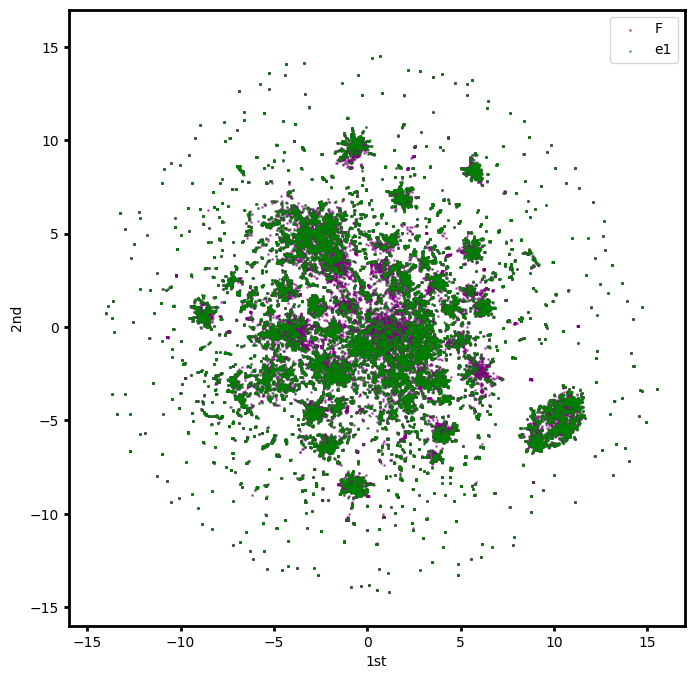

In [8]:
fig = plt.figure(figsize=(8,8))
plt.scatter(MF_umap_F['UMAP_0'], MF_umap_F['UMAP_1'], color='purple', label='F', s=1, alpha=0.5)
plt.scatter(MF_umap_e1['UMAP_0'], MF_umap_e1['UMAP_1'], color='green', label='e1', s=1, alpha=0.5)
plt.xlabel("1st")
plt.ylabel("2nd")
plt.xlim(-16, 17)
plt.ylim(-16, 17)
plt.xticks(np.arange(-15, 16, 5))
plt.yticks(np.arange(-15, 16, 5))
plt.gca().set_aspect('equal')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(width=2)
plt.legend()
plt.show()

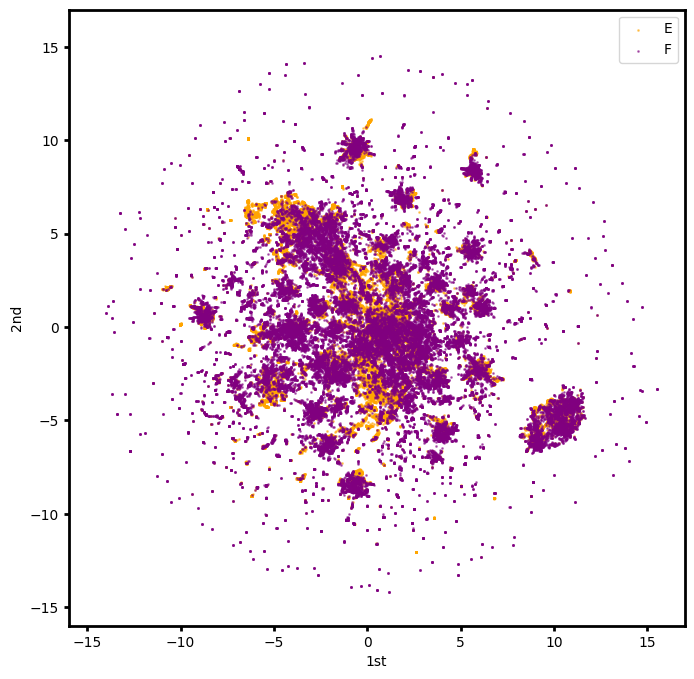

In [9]:
fig = plt.figure(figsize=(8,8))
plt.scatter(MF_umap_E['UMAP_0'], MF_umap_E['UMAP_1'], color='orange', label='E', s=1, alpha=0.5)
plt.scatter(MF_umap_F['UMAP_0'], MF_umap_F['UMAP_1'], color='purple', label='F', s=1, alpha=0.5)
plt.xlabel("1st")
plt.ylabel("2nd")
plt.xlim(-16, 17)
plt.ylim(-16, 17)
plt.xticks(np.arange(-15, 16, 5))
plt.yticks(np.arange(-15, 16, 5))
plt.gca().set_aspect('equal')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(width=2)
plt.legend()
plt.show()